In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
import torch
import random
import os

# --- CONFIGURATION ---
CONFIG = {
    "WINDOW_SIZE": 60,       
    "TX_COST_BPS": 0.0010,   
    "RISK_AVERSION": 4.0,    
    "REBALANCE_DAYS": 20,
    # Strategy Params (Winner from Optimization)
    "PANIC_VOL": 0.0209,      
    "STRONG_TREND": 0.0065,
    "REBALANCE_THRESHOLD": 0.05,
    "COOLDOWN_DAYS": 3
}

# --- REPRODUCIBILITY ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("./logs/", exist_ok=True) # Folder for best model
print("✓ Config Loaded.")

✓ Config Loaded.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
class FinancialFeatureEngineer:
    def preprocess_data(self, df):
        data = df.copy()
        asset_cols = [c for c in data.columns if c != 'QQQ']
        
        log_ret = np.log(data[asset_cols] / data[asset_cols].shift(1)).fillna(0)
        
        # Features
        roll_std = log_ret.rolling(20).std()
        norm_vol = (roll_std - roll_std.rolling(252).mean()) / (roll_std.rolling(252).std() + 1e-8)
        
        delta = data[asset_cols].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / (loss + 1e-8)
        norm_rsi = (100 - (100 / (1 + rs)) - 50) / 50 
        
        sma_50 = data[asset_cols].rolling(50).mean()
        dist_sma = (data[asset_cols] / sma_50) - 1.0

        asset_cum = data[asset_cols].pct_change(60)
        bench_cum = data['QQQ'].pct_change(60)
        rel_str = asset_cum.sub(bench_cum, axis=0)
        
        market_ret = log_ret.mean(axis=1) 
        rolling_cov = log_ret.rolling(60).cov(market_ret)
        rolling_var = market_ret.rolling(60).var()
        beta = (rolling_cov.div(rolling_var, axis=0)).fillna(1.0)

        features = np.stack([
            norm_vol.fillna(0).clip(-3, 3).values, 
            norm_rsi.fillna(0).clip(-1, 1).values, 
            dist_sma.fillna(0).clip(-0.5, 0.5).values, 
            rel_str.fillna(0).clip(-0.5, 0.5).values,
            beta.fillna(1.0).clip(-2, 2).values, 
            log_ret.values
        ], axis=-1)
        
        return features.astype(np.float32), data[asset_cols].values.astype(np.float32), data['QQQ'].values.astype(np.float32), asset_cols

def get_data():
    from datetime import datetime
    tickers = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG', 'QQQ']
    print(f"📥 Downloading {len(tickers)} assets...")
    try:
        # Explicitly set auto_adjust=False to ensure 'Adj Close' is returned
        # group_by='column' ensures we can select 'Adj Close' easily
        raw_data = yf.download(tickers, start="2015-01-01", end=datetime.now().strftime("%Y-%m-%d"), auto_adjust=False, group_by='column')
        
        if 'Adj Close' in raw_data.columns:
             data = raw_data['Adj Close']
        elif isinstance(raw_data.columns, pd.MultiIndex):
             # Fallback: try to find Adj Close in levels or just take Close if Adj Close missing
             data = raw_data.xs('Adj Close', level=0, axis=1, drop_level=True)
        else:
             # If flat and no Adj Close, maybe just Close?
             data = raw_data['Close']
             
        if data.empty: raise ValueError('Data is empty')
        
        # Ensure we have a flat index (Tickers as columns)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(-1)
            
        return data.dropna()
    except Exception as e:
        print(f"⚠️ Data Download Failed or Empty. Check API. Error: {e}")
        return pd.DataFrame()
        

df = get_data()
engineer = FinancialFeatureEngineer()
features, prices, benchmark, ticker_names = engineer.preprocess_data(df)

# === 3-WAY SPLIT: Train (60%), Validation (20%), Test (20%) ===
n = len(df)
idx_train = int(n * 0.60)
idx_val = int(n * 0.80)

feat_train, price_train, bench_train = features[:idx_train], prices[:idx_train], benchmark[:idx_train]
feat_val, price_val, bench_val = features[idx_train:idx_val], prices[idx_train:idx_val], benchmark[idx_train:idx_val]
feat_test, price_test, bench_test = features[idx_val:], prices[idx_val:], benchmark[idx_val:]

print(f"✅ Data Split: Train={len(price_train)}, Val={len(price_val)} (For Callback), Test={len(price_test)}")

📥 Downloading 8 assets...


[*********************100%***********************]  8 of 8 completed

✅ Data Split: Train=1646, Val=549 (For Callback), Test=549


In [3]:
class PortfolioRebalanceEnv(gym.Env):
    def __init__(self, price_data, features_data, benchmark_data, initial_balance=100_000):
        super().__init__()
        self.prices = price_data
        self.features = features_data
        self.benchmark = benchmark_data
        self.n_assets = self.prices.shape[1]
        self.n_features = self.features.shape[2]
        self.lookback = CONFIG["WINDOW_SIZE"]
        self.initial_balance = initial_balance
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-10, high=10, shape=(self.lookback, self.n_assets, self.n_features), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        buffer = CONFIG["REBALANCE_DAYS"] + 5
        max_start = len(self.prices) - buffer - 1
        self.curr_step = np.random.randint(self.lookback, max_start) if max_start > self.lookback else self.lookback
        self.cash = float(self.initial_balance)
        self.shares = np.zeros(self.n_assets, dtype=np.float32)
        self.portfolio_value = float(self.initial_balance)
        self.history_nav = [self.portfolio_value]
        return self._get_obs(), {}

    def step(self, action):
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        
        current_p = self.prices[self.curr_step]
        target_val = self.portfolio_value * weights[:-1]
        current_val = self.shares * current_p
        trade_cost = np.sum(np.abs(target_val - current_val)) * CONFIG["TX_COST_BPS"]
        
        self.cash = (self.portfolio_value * weights[-1]) - trade_cost
        self.shares = target_val / current_p
        
        steps = min(CONFIG["REBALANCE_DAYS"], len(self.prices) - self.curr_step - 1)
        if steps <= 0: return self._get_obs(), 0.0, True, False, {}
            
        rewards = []
        for _ in range(steps):
            self.curr_step += 1
            new_val = self.cash + np.sum(self.shares * self.prices[self.curr_step])
            rewards.append(np.log(new_val / self.history_nav[-1]))
            self.history_nav.append(new_val)
            
        self.portfolio_value = self.history_nav[-1]
        r = np.array(rewards)
        reward = np.mean(r) - (CONFIG["RISK_AVERSION"] * (np.std(r[r<0]) if len(r[r<0]) > 0 else 0.0))
        
        return self._get_obs(), reward, self.curr_step >= len(self.prices) - 2, False, {}

    def _get_obs(self):
        return self.features[self.curr_step - self.lookback : self.curr_step]

In [4]:
# === TRAINING WITH CALLBACK ===
print("Training Alpha Agent with Validation...")

# 1. Training Env
train_env = DummyVecEnv([lambda: PortfolioRebalanceEnv(price_train, feat_train, bench_train)])
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.)

# 2. Validation Env (Used by Callback to test the agent)
# Note: We do NOT normalize rewards in validation, we want raw performance
eval_env = DummyVecEnv([lambda: PortfolioRebalanceEnv(price_val, feat_val, bench_val)])
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10.)

# 3. Setup Callback
# eval_freq=1000: Check performance every 1000 steps
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path='./logs/',
    log_path='./logs/', 
    eval_freq=1000, 
    deterministic=True, 
    render=False,
    verbose=1
)

# 4. Train
model = PPO("MlpPolicy", train_env, verbose=0, learning_rate=3e-4, ent_coef=0.01)
model.learn(total_timesteps=50_000, callback=eval_callback)

print("✓ Training Complete.")

# 5. LOAD THE BEST MODEL (The Solution)
# We discard the final state and load the one that won the callback check
best_model = PPO.load("./logs/best_model")
print("✓ Loaded Best Model from Validation.")

# Save normalization stats to apply to Test set later
train_env.save("vec_normalize.pkl")

Training Alpha Agent with Validation...


/Users/nataliamarko/miniconda3/envs/demand_forecast_env/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=1000, episode_reward=-0.45 +/- 0.27
Episode length: 13.20 +/- 5.71
New best mean reward!
Eval num_timesteps=2000, episode_reward=-0.41 +/- 0.25
Episode length: 12.20 +/- 5.53
New best mean reward!
Eval num_timesteps=3000, episode_reward=-0.37 +/- 0.23
Episode length: 10.40 +/- 5.50
New best mean reward!
Eval num_timesteps=4000, episode_reward=-0.63 +/- 0.36
Episode length: 16.20 +/- 7.68
Eval num_timesteps=5000, episode_reward=-0.57 +/- 0.26
Episode length: 15.20 +/- 5.84
Eval num_timesteps=6000, episode_reward=-0.47 +/- 0.36
Episode length: 12.20 +/- 8.18
Eval num_timesteps=7000, episode_reward=-0.41 +/- 0.40
Episode length: 10.20 +/- 9.28
Eval num_timesteps=8000, episode_reward=-0.32 +/- 0.31
Episode length: 8.80 +/- 7.19
New best mean reward!
Eval num_timesteps=9000, episode_reward=-0.40 +/- 0.24
Episode length: 12.00 +/- 4.90
Eval num_timesteps=10000, episode_reward=-0.46 +/- 0.26
Episode length: 13.40 +/- 5.31
Eval num_timesteps=11000, episode_reward=-0.42 +/- 0

In [5]:
class AlphaHunterStrategy:
    def __init__(self, model, tickers, panic_vol, strong_trend, rebalance_threshold, cooldown=3):
        self.model = model
        self.tickers = tickers
        self.panic_vol = panic_vol
        self.strong_trend = strong_trend
        self.rebalance_threshold = rebalance_threshold
        self.cooldown = cooldown
        self.days_since_crash = 999 
        
    def _softmax(self, x):
        e = np.exp(x - np.max(x)); return e / e.sum()

    def predict(self, obs, market_vol, trend_strength):
        action, _ = self.model.predict(obs, deterministic=True)
        if action.ndim > 1: action = action[0]
        weights = self._softmax(action) 
        regime = "NORMAL"
        
        self.days_since_crash += 1
        
        # 1. CRASH LOGIC
        if market_vol > self.panic_vol:
            regime = "CRASH"
            self.days_since_crash = 0
        elif self.days_since_crash < self.cooldown:
            regime = "CRASH" # Stay in safety
            
        # 2. RALLY LOGIC
        elif trend_strength > self.strong_trend:
            regime = "RALLY"

        # 3. APPLY REGIME
        if regime == "CRASH":
            weights = np.zeros_like(weights); weights[-1] = 1.0
        elif regime == "RALLY":
            weights[-1] = 0.0 # No Cash
            if np.sum(weights) > 0: weights /= np.sum(weights)
                
        return weights, regime

Running Final Test on 549 days...


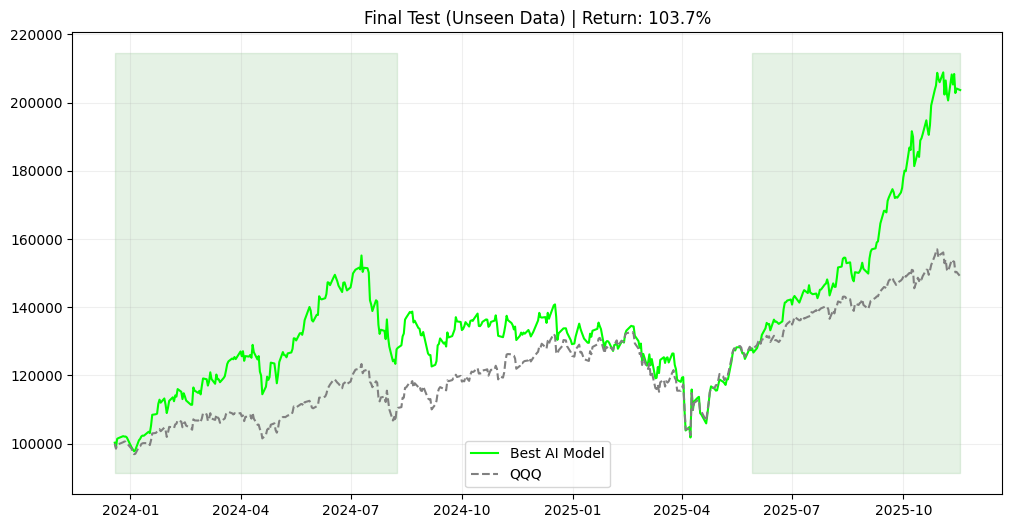

In [6]:
# === FINAL BACKTEST ===
def run_final_test(strategy, test_env, df_dates, prices_raw, bench_raw):
    raw_env = test_env.envs[0]
    curr_step = raw_env.lookback
    obs = test_env.reset()
    
    portfolio_val = 100_000.0
    cash = 100_000.0
    shares = np.zeros(len(strategy.tickers))
    history = []
    
    print(f"Running Final Test on {len(prices_raw)} days...")
    
    while curr_step < len(prices_raw) - CONFIG["REBALANCE_DAYS"] - 2:
        # Signals
        bench_slice = bench_raw[curr_step-5 : curr_step]
        mkt_vol = np.std(pd.Series(bench_slice).pct_change()) if len(bench_slice) > 1 else 0.01
        raw_feats = raw_env.features[curr_step-1]
        avg_trend = np.mean(raw_feats[:, 3]) 
        
        # Predict
        target_weights, regime = strategy.predict(obs, mkt_vol, avg_trend)
        
        # Rebalance Threshold
        current_p = prices_raw[curr_step]
        current_val_per_asset = shares * current_p
        if portfolio_val > 0:
            current_w = np.append(current_val_per_asset / portfolio_val, cash / portfolio_val)
        else:
            current_w = np.zeros_like(target_weights); current_w[-1] = 1.0
            
        deviation = np.sum(np.abs(target_weights - current_w))
        active_threshold = 0.01 if regime != "NORMAL" else strategy.rebalance_threshold
        
        if deviation > active_threshold:
            target_val = portfolio_val * target_weights[:-1]
            cost = np.sum(np.abs(target_val - current_val_per_asset)) * CONFIG["TX_COST_BPS"]
            cash = (portfolio_val * target_weights[-1]) - cost
            shares = target_val / current_p
            
        # Sim
        for _ in range(CONFIG["REBALANCE_DAYS"]):
            curr_step += 1
            portfolio_val = cash + np.sum(shares * prices_raw[curr_step])
            history.append({'date': df_dates[curr_step], 'nav': portfolio_val, 'regime': regime, 'benchmark': bench_raw[curr_step]})
            
        raw_env.curr_step = curr_step
        obs = test_env.reset()
        
    return pd.DataFrame(history).set_index('date')

# Setup Test Env
final_test_env = DummyVecEnv([lambda: PortfolioRebalanceEnv(price_test, feat_test, bench_test)])
final_test_env = VecNormalize.load("vec_normalize.pkl", final_test_env)
final_test_env.training = False
final_test_env.norm_reward = False

# Strategy using Best Model + Optimized Params
strat = AlphaHunterStrategy(best_model, ticker_names, 
                            CONFIG["PANIC_VOL"], CONFIG["STRONG_TREND"], 
                            CONFIG["REBALANCE_THRESHOLD"], CONFIG["COOLDOWN_DAYS"])

results = run_final_test(strat, final_test_env, df.index[idx_val:], price_test, bench_test)

# Plot
plt.figure(figsize=(12, 6))
res = results.copy()
res['bench_norm'] = (res['benchmark'] / res['benchmark'].iloc[0]) * 100000
plt.plot(res.index, res['nav'], label='Best AI Model', color='#00ff00')
plt.plot(res.index, res['bench_norm'], label='QQQ', color='gray', linestyle='--')

y_min, y_max = plt.gca().get_ylim()
plt.fill_between(res.index, y_min, y_max, where=(res['regime']=='RALLY'), color='green', alpha=0.1)
plt.fill_between(res.index, y_min, y_max, where=(res['regime']=='CRASH'), color='red', alpha=0.1)

plt.title(f"Final Test (Unseen Data) | Return: {((res['nav'].iloc[-1]/100000)-1)*100:.1f}%")
plt.legend(); plt.grid(True, alpha=0.2); plt.show()

running Sensitivity Analysis...
Testing Volatility: 0.0167 to 0.0251
Testing Trend: 0.0052 to 0.0078
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...
Running Final Test on 549 days...


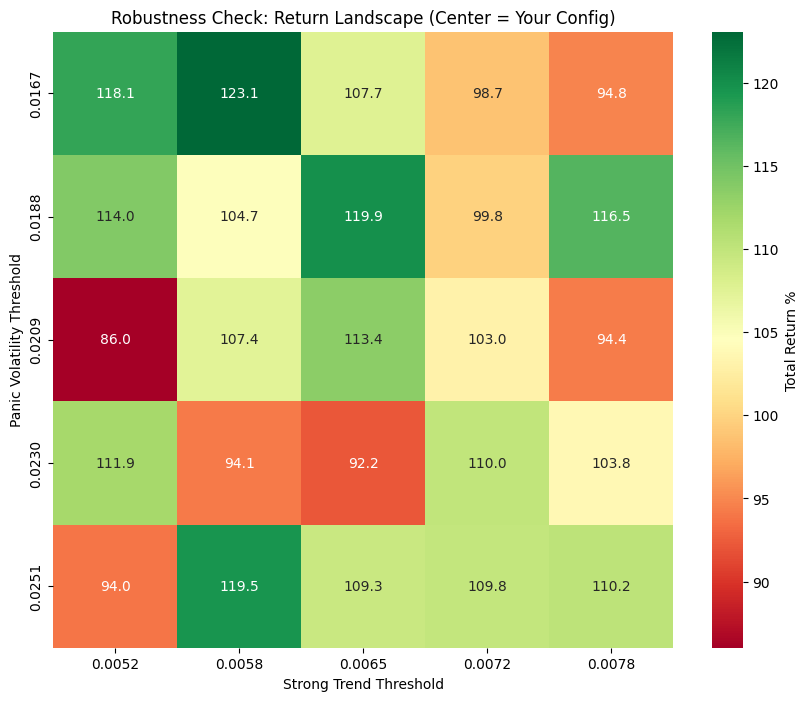

In [8]:
# === BLOCK 7: SENSITIVITY AUDIT ===
import seaborn as sns

print("running Sensitivity Analysis...")

# 1. Define the Range to Test (e.g., +/- 20% around best params)
# We test the interaction between Panic Vol and Trend (the two most critical)
BEST_PANIC = CONFIG["PANIC_VOL"]
BEST_TREND = CONFIG["STRONG_TREND"]

vol_range = np.linspace(BEST_PANIC * 0.8, BEST_PANIC * 1.2, 5)
trend_range = np.linspace(BEST_TREND * 0.8, BEST_TREND * 1.2, 5)

# 2. Run Grid Search
heatmap_data = []
print(f"Testing Volatility: {vol_range[0]:.4f} to {vol_range[-1]:.4f}")
print(f"Testing Trend: {trend_range[0]:.4f} to {trend_range[-1]:.4f}")

for v in vol_range:
    row = []
    for t in trend_range:
        # Update Strategy with temporary params
        test_strat = AlphaHunterStrategy(
            best_model, 
            ticker_names, 
            panic_vol=v, 
            strong_trend=t, 
            rebalance_threshold=CONFIG["REBALANCE_THRESHOLD"],
            cooldown=CONFIG["COOLDOWN_DAYS"]
        )
        
        # Run Fast Backtest on TEST SET
        try:
            res = run_final_test(test_strat, final_test_env, df.index[idx_val:], price_test, bench_test)
            total_return = ((res['nav'].iloc[-1] / 100000) - 1) * 100
            row.append(total_return)
        except:
            row.append(0.0)
    heatmap_data.append(row)

# 3. Visualization
plt.figure(figsize=(10, 8))
df_heat = pd.DataFrame(heatmap_data, 
                       index=[f"{x:.4f}" for x in vol_range], 
                       columns=[f"{x:.4f}" for x in trend_range])

sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={'label': 'Total Return %'})
plt.title(f"Robustness Check: Return Landscape (Center = Your Config)")
plt.ylabel("Panic Volatility Threshold")
plt.xlabel("Strong Trend Threshold")
plt.show()